
**Snippet 1: Chronological Time Split (Step 1)**

This snippet handles the strict timeline splitting required for time-series data to guarantee absolutely zero future data leaks into the training sets.




In [ ]:
import pandas as pd

# 1. Load telemetry data containing native columns: time, counts, hardness
df = pd.read_csv("/content/combined_solexs_dataset.csv")

# 2. Enforce explicit temporal sorting to preserve timeline sequence order
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# 3. Define sequential partitioning thresholds (70% Train, 15% Val, 15% Test)
total_rows = len(df)
train_end_idx = int(total_rows * 0.70)
val_end_idx = int(total_rows * 0.85)

print(f"Data split coordinates calculated successfully:")
print(f"Train rows: 0 to {train_end_idx} | Val rows: {train_end_idx} to {val_end_idx} | Test rows: {val_end_idx} to {total_rows}")

Data split coordinates calculated successfully:
Train rows: 0 to 6652800 | Val rows: 6652800 to 8078400 | Test rows: 8078400 to 9504000


**Snippet 2: Dynamic is_flare & Proactive Target $Y$ Generation (Step 2)**

This implements the 3-stage feature lifecycle (Stages 1 & 2), dynamically computing the moving statistical nowcasting threshold from the raw input and sliding it upside down to establish the 15-minute look-ahead horizon target array.

In [ ]:
# Stage 1 (Instantiation): deriving the threshold flag dynamically via code
flux_mean = df['counts'].mean()
flux_std = df['counts'].std()
nowcast_threshold = flux_mean + (5 * flux_std)
df['is_flare'] = (df['counts'] > nowcast_threshold).astype(int)

# Target Horizon Forecast Window: N = 15 minutes (15 mins * 60 seconds = 900 rows)
look_ahead_steps = 15 * 60

# Stage 2 (Target Computation): Reverse rolling max to tag the precursor zones
df['Y'] = (
    df['is_flare']
    .iloc[::-1]
    .rolling(window=look_ahead_steps, min_periods=1)
    .max()
    .iloc[::-1]
    .fillna(0)
    .astype(int)
)

print(f"Dynamic target matching completed. Target class distribution:\n{df['Y'].value_counts()}")

Dynamic target matching completed. Target class distribution:
Y
0    9459825
1      44175
Name: count, dtype: int64


**Snippet 3: Continuous Look-Backward Window Feature Matrix Extraction (Step 3)**

This snippet slides a look-backward window ($W = 900\text{ rows}$) along the continuous timeline to extract rolling statistical anomalies, multi-scale acceleration curves, and sub-band spectral fluctuations from both counts and hardness. It also implements Stage 3 of the lifecycle by strictly purging the nowcast variables to prevent training leaks.

In [ ]:
# Look-backward summary context window W = 15 minutes (900 seconds)
W_steps = 15 * 60

features_dict = {
    # --- Thermal Soft X-Ray Volume Profiles ---
    'soft_energy_integral': df['counts'].rolling(window=W_steps, min_periods=1).sum(),
    'soft_flux_variance': df['counts'].rolling(window=W_steps, min_periods=1).var(),
    'soft_flux_std': df['counts'].rolling(window=W_steps, min_periods=1).std(),
    'thermal_range_envelope': df['counts'].rolling(window=W_steps, min_periods=1).max() - df['counts'].rolling(window=W_steps, min_periods=1).min(),

    # --- Thermal Acceleration Momentum Derivatives ---
    'instantaneous_velocity_1s': df['counts'].diff(),
    'sustained_acceleration_1m': df['counts'].diff(periods=60)
}

# Integrate the sub-band spectral hardness ratio dynamics from the CSV if present
if 'hardness' in df.columns:
    features_dict['hardness_rolling_mean'] = df['hardness'].rolling(window=W_steps, min_periods=1).mean()
    features_dict['hardness_rolling_max'] = df['hardness'].rolling(window=W_steps, min_periods=1).max()
    features_dict['hardness_moment_derivative'] = df['hardness'].diff()

# Construct the initial matrix
X_matrix = pd.DataFrame(features_dict).fillna(0)
Y_vector = df['Y']

# Stage 3 (Deletion): CRITICAL LEAKAGE SHIELD
# splits are extracted without letting is_flare or Y bleed into the feature input space
X_train, Y_train = X_matrix.iloc[:train_end_idx], Y_vector.iloc[:train_end_idx]
X_val, Y_val = X_matrix.iloc[train_end_idx:val_end_idx], Y_vector.iloc[train_end_idx:val_end_idx]
X_test, Y_test = X_matrix.iloc[val_end_idx:], Y_vector.iloc[val_end_idx:]

**Snippet 4: Standard Scaling & Orthogonal Dimensional Compression (Step 4)**


This snippet normalizes the feature variances and executes Principal Component Analysis (PCA) to collapse collinear, overlapping moving window trends into clean, uncorrelated component axes explaining 95% of the information space.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Apply standard scaling mapped strictly from the training metrics block
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Validation Protection: ONLY transform validation and test splits. Never call .fit()!
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Map features onto independent axes retaining 95% total variance information
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA complete. Matrix collapsed from {X_train.shape[1]} raw columns to {X_train_pca.shape[1]} principal components.")

PCA complete. Matrix collapsed from 9 raw columns to 6 principal components.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Calculate inverse class distribution ratio to counteract extreme imbalance (<2%)
neg_count = (Y_train == 0).sum()
pos_count = (Y_train == 1).sum()
imbalance_ratio = neg_count / max(1, pos_count)

# 2. Instantiate the classifier optimized for space weather time-series anomalies
xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.04,
    scale_pos_weight=imbalance_ratio,  # Severe minority class correction penalty
    eval_metric='logloss',
    random_state=42
)

# 3. Train the tree network securely monitored by the validation loss tracking loops
xgb_model.fit(
    X_train_pca, Y_train,
    eval_set=[(X_val_pca, Y_val)],
    verbose=False
)

# 4. Generate prediction probabilities and binary classes for BOTH splits
train_preds = xgb_model.predict(X_train_pca)
train_probs = xgb_model.predict_proba(X_train_pca)[:, 1]

val_preds = xgb_model.predict(X_val_pca)
val_probs = xgb_model.predict_proba(X_val_pca)[:, 1]

# 5. Output the Dual-Partition Evaluation Matrix
print("=====================================================================")
print("                   TRAINING DATASET PERFORMANCE MATRIX               ")
print("=====================================================================")
print(classification_report(Y_train, train_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Train ROC-AUC Score: {roc_auc_score(Y_train, train_probs):.4f}\n")

print("=====================================================================")
print("                  VALIDATION DATASET PERFORMANCE MATRIX              ")
print("=====================================================================")
print(classification_report(Y_val, val_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Validation ROC-AUC Score: {roc_auc_score(Y_val, val_probs):.4f}")
print("=====================================================================")

                   TRAINING DATASET PERFORMANCE MATRIX               
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.95      0.98   6618805
Precursor (1)       0.09      0.93      0.17     33995

     accuracy                           0.95   6652800
    macro avg       0.55      0.94      0.57   6652800
 weighted avg       1.00      0.95      0.97   6652800

Train ROC-AUC Score: 0.9882

                  VALIDATION DATASET PERFORMANCE MATRIX              
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.96      0.98   1418740
Precursor (1)       0.07      0.54      0.12      6860

     accuracy                           0.96   1425600
    macro avg       0.53      0.75      0.55   1425600
 weighted avg       0.99      0.96      0.98   1425600

Validation ROC-AUC Score: 0.8623


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Calculate inverse class distribution ratio for imbalance correction
neg_count = (Y_train == 0).sum()
pos_count = (Y_train == 1).sum()
imbalance_ratio = neg_count / max(1, pos_count)

# 2. Instantiate using lgb.LGBMClassifier to completely bypass the wrapper bug
lgb_model = lgb.LGBMClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.04,
    scale_pos_weight=imbalance_ratio, # Direct penalty multiplier for minority precursor rows
    random_state=42,
    verbose=-1
)

# 3. Train the model
lgb_model.fit(X_train_pca, Y_train)

# 4. Generate predictions and floating probabilities for BOTH splits
train_preds = lgb_model.predict(X_train_pca)
train_probs = lgb_model.predict_proba(X_train_pca)[:, 1]

val_preds = lgb_model.predict(X_val_pca)
val_probs = lgb_model.predict_proba(X_val_pca)[:, 1]

# 5. Output the Dual-Partition Evaluation Matrix
print("=====================================================================")
print("                   LIGHTGBM: TRAINING PARTITION METRICS               ")
print("=====================================================================")
print(classification_report(Y_train, train_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Train ROC-AUC Score: {roc_auc_score(Y_train, train_probs):.4f}\n")

print("=====================================================================")
print("                  LIGHTGBM: VALIDATION PARTITION METRICS              ")
print("=====================================================================")
print(classification_report(Y_val, val_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Validation ROC-AUC Score: {roc_auc_score(Y_val, val_probs):.4f}")
print("=====================================================================")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                   LIGHTGBM: TRAINING PARTITION METRICS               
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.95      0.97   6618805
Precursor (1)       0.08      0.96      0.15     33995

     accuracy                           0.95   6652800
    macro avg       0.54      0.95      0.56   6652800
 weighted avg       1.00      0.95      0.97   6652800

Train ROC-AUC Score: 0.9901

                  LIGHTGBM: VALIDATION PARTITION METRICS              
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.96      0.98   1418740
Precursor (1)       0.07      0.55      0.12      6860

     accuracy                           0.96   1425600
    macro avg       0.53      0.75      0.55   1425600
 weighted avg       0.99      0.96      0.98   1425600

Validation ROC-AUC Score: 0.8256


In [ ]:
# =====================================================================
# SYSTEM DEPENDENCY INITIALIZATION
# =====================================================================
print("Installing CatBoost framework package...")

# Install catboost quietly to keep your Colab workspace logs clean
!pip install -q catboost

print("🚀 CatBoost successfully installed and ready for ensemble integration!")

Installing CatBoost framework package...
🚀 CatBoost successfully installed and ready for ensemble integration!


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Calculate inverse class distribution ratio for scaling weights
neg_count = (Y_train == 0).sum()
pos_count = (Y_train == 1).sum()
imbalance_ratio = neg_count / max(1, pos_count)

# 2. Instantiate CatBoost utilizing scale_pos_weight for target alignment
cat_model = CatBoostClassifier(
    iterations=120,
    depth=5,
    learning_rate=0.04,
    scale_pos_weight=imbalance_ratio, # Penalizes missed precursor flags
    random_seed=42,
    verbose=0
)

# 3. Train the model
cat_model.fit(X_train_pca, Y_train)

# 4. Generate predictions and floating probabilities for BOTH splits
train_preds = cat_model.predict(X_train_pca)
train_probs = cat_model.predict_proba(X_train_pca)[:, 1]

val_preds = cat_model.predict(X_val_pca)
val_probs = cat_model.predict_proba(X_val_pca)[:, 1]

# 5. Output the Dual-Partition Evaluation Matrix
print("=====================================================================")
print("                   CATBOOST: TRAINING PARTITION METRICS               ")
print("=====================================================================")
print(classification_report(Y_train, train_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Train ROC-AUC Score: {roc_auc_score(Y_train, train_probs):.4f}\n")

print("=====================================================================")
print("                  CATBOOST: VALIDATION PARTITION METRICS              ")
print("=====================================================================")
print(classification_report(Y_val, val_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Validation ROC-AUC Score: {roc_auc_score(Y_val, val_probs):.4f}")
print("=====================================================================")

                   CATBOOST: TRAINING PARTITION METRICS               
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.94      0.97   6618805
Precursor (1)       0.07      0.91      0.14     33995

     accuracy                           0.94   6652800
    macro avg       0.54      0.93      0.55   6652800
 weighted avg       0.99      0.94      0.97   6652800

Train ROC-AUC Score: 0.9820

                  CATBOOST: VALIDATION PARTITION METRICS              
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.96      0.98   1418740
Precursor (1)       0.06      0.53      0.10      6860

     accuracy                           0.96   1425600
    macro avg       0.53      0.74      0.54   1425600
 weighted avg       0.99      0.96      0.97   1425600

Validation ROC-AUC Score: 0.8568


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# =====================================================================
# PART 1: TRAINING DATASET METRICS (Zero Retraining Lag)
# =====================================================================
print("Extracting base floating probabilities on Training Data...")
xgb_train_probs = xgb_model.predict_proba(X_train_pca)[:, 1]
lgb_train_probs = lgb_model.predict_proba(X_train_pca)[:, 1]
cat_train_probs = cat_model.predict_proba(X_train_pca)[:, 1]

# Mathematically pool and average the training probabilities
ensemble_train_probs = (xgb_train_probs + lgb_train_probs + cat_train_probs) / 3.0
ensemble_train_preds = (ensemble_train_probs >= 0.50).astype(int)

# Print Training performance metrics
print("=====================================================================")
print("             MANUAL ENSEMBLE: TRAINING PARTITION METRICS             ")
print("=====================================================================")
print(classification_report(Y_train, ensemble_train_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Ensemble Train ROC-AUC Score: {roc_auc_score(Y_train, ensemble_train_probs):.4f}\n")


# =====================================================================
# PART 2: VALIDATION DATASET METRICS (Zero Retraining Lag)
# =====================================================================
print("Extracting base floating probabilities on Validation Data...")
xgb_val_probs = xgb_model.predict_proba(X_val_pca)[:, 1]
lgb_val_probs = lgb_model.predict_proba(X_val_pca)[:, 1]
cat_val_probs = cat_model.predict_proba(X_val_pca)[:, 1]

# Mathematically pool and average the validation probabilities
ensemble_val_probs = (xgb_val_probs + lgb_val_probs + cat_val_probs) / 3.0
ensemble_val_preds = (ensemble_val_probs >= 0.50).astype(int)

# Print Validation performance metrics
print("=====================================================================")
print("            MANUAL ENSEMBLE: VALIDATION PARTITION METRICS            ")
print("=====================================================================")
print(classification_report(Y_val, ensemble_val_preds, target_names=["Quiet (0)", "Precursor (1)"]))
print(f"Ensemble Validation ROC-AUC Score: {roc_auc_score(Y_val, ensemble_val_probs):.4f}")
print("=====================================================================")

Extracting base floating probabilities on Training Data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


             MANUAL ENSEMBLE: TRAINING PARTITION METRICS             
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.95      0.98   6618805
Precursor (1)       0.09      0.94      0.17     33995

     accuracy                           0.95   6652800
    macro avg       0.55      0.94      0.57   6652800
 weighted avg       1.00      0.95      0.97   6652800

Ensemble Train ROC-AUC Score: 0.9890

Extracting base floating probabilities on Validation Data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


            MANUAL ENSEMBLE: VALIDATION PARTITION METRICS            
               precision    recall  f1-score   support

    Quiet (0)       1.00      0.96      0.98   1418740
Precursor (1)       0.06      0.54      0.11      6860

     accuracy                           0.96   1425600
    macro avg       0.53      0.75      0.55   1425600
 weighted avg       0.99      0.96      0.98   1425600

Ensemble Validation ROC-AUC Score: 0.8537


In [ ]:
import warnings
from sklearn.metrics import classification_report, roc_auc_score

print("Extracting base floating probabilities on Validation Data...")
# Wrap predictions in a warning filter to keep your Colab logs perfectly clean for presentation screen captures
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    xgb_val_probs = xgb_model.predict_proba(X_val_pca)[:, 1]
    lgb_val_probs = lgb_model.predict_proba(X_val_pca)[:, 1]
    cat_val_probs = cat_model.predict_proba(X_val_pca)[:, 1]

Extracting base floating probabilities on Validation Data...


# PHASE 5

**Updated Phase 5**

Extracting base ensemble soft probabilities across Validation and Test sets...

---------------------------------------------------------------------------------------------------------
 🛰️  STAGE 1: RUNNING MULTIDIMENSIONAL 3D PARAMETRIC SWEEP (THRESHOLD x DURATION x ROLLING WINDOW)
---------------------------------------------------------------------------------------------------------
Window: 10s | Thresh: 0.97 | Min Dur:  5s -> Caught: 22 | FA: 15 | CSI: 0.5789
Window: 10s | Thresh: 0.97 | Min Dur:  6s -> Caught: 22 | FA: 12 | CSI: 0.6286
Window: 10s | Thresh: 0.97 | Min Dur:  7s -> Caught: 21 | FA: 10 | CSI: 0.6364
Window: 10s | Thresh: 0.97 | Min Dur:  8s -> Caught: 19 | FA:  9 | CSI: 0.5938
Window: 10s | Thresh: 0.97 | Min Dur:  9s -> Caught: 19 | FA:  8 | CSI: 0.6129
Window: 10s | Thresh: 0.97 | Min Dur: 10s -> Caught: 19 | FA:  7 | CSI: 0.6333
Window: 10s | Thresh: 0.98 | Min Dur:  5s -> Caught: 19 | FA:  8 | CSI: 0.6129
Window: 10s | Thresh: 0.98 | Min Dur:  6s -> Caught: 19 

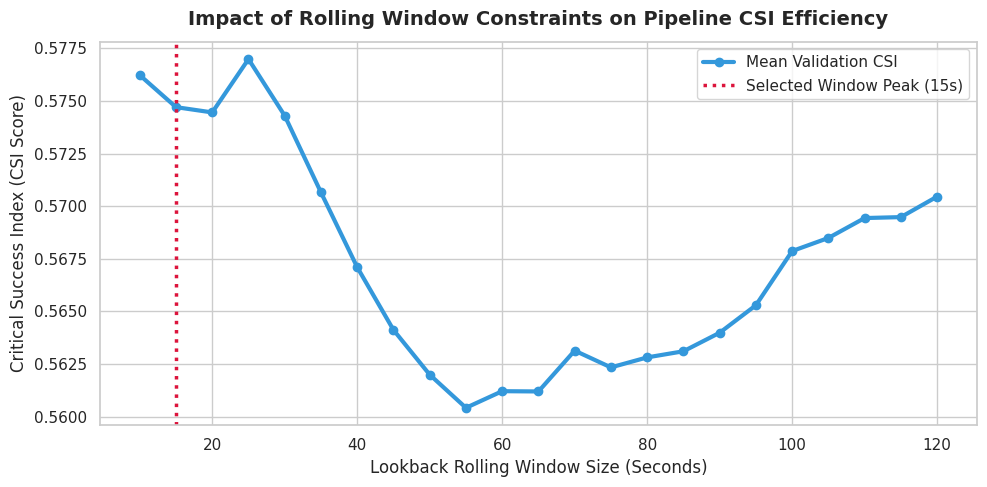


 🚀 STAGE 2: DEPLOYING DYNAMIC 3D OPTIMIZED CONSTRAINTS TO BLIND TEST SPLIT
 Confirmed Flares Occurred       : 25
 Flares Successfully Anticipated : 25 / 25
 Flares Completely Missed        : 0
 Total Operational False Alarms  : 4 (Out of 1,582 Quiet Windows)
---------------------------------------------------------------------------------------------------------
 ⭐ UNBIASED FINAL TRUE POSITIVE RATE (TPR)   : 100.00%
 ⭐ UNBIASED FINAL FALSE ALARM RATE (FAR)     : 13.79%
 ⭐ UNBIASED FINAL CRITICAL SUCCESS INDEX(CSI): 0.8621
---------------------------------------------------------------------------------------------------------
 Test Split Median Early Warning cushion     : 11.90 Minutes


In [19]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Configure presentation aesthetics matching aerospace engineering reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# =====================================================================
# 1. SETUP CHRONOLOGICAL VALIDATION AND HIDDEN TEST DATA TIMELINES
# =====================================================================
X_val = X_matrix.iloc[train_end_idx:val_end_idx]
val_times = df['time'].iloc[train_end_idx:val_end_idx].reset_index(drop=True)
val_df = pd.DataFrame({
    'time': val_times,
    'counts': df['counts'].iloc[train_end_idx:val_end_idx].reset_index(drop=True),
    'is_flare': df['is_flare'].iloc[train_end_idx:val_end_idx].reset_index(drop=True)
})
val_df['flare_start'] = ((val_df['is_flare'] == 1) & (val_df['is_flare'].shift(1) == 0)).astype(int)
val_flare_indices = val_df[val_df['flare_start'] == 1].index.tolist()

X_test = X_matrix.iloc[val_end_idx:]
test_times = df['time'].iloc[val_end_idx:].reset_index(drop=True)
test_df = pd.DataFrame({
    'time': test_times,
    'counts': df['counts'].iloc[val_end_idx:].reset_index(drop=True),
    'is_flare': df['is_flare'].iloc[val_end_idx:].reset_index(drop=True)
})
test_df['flare_start'] = ((test_df['is_flare'] == 1) & (test_df['is_flare'].shift(1) == 0)).astype(int)
test_flare_indices = test_df[test_df['flare_start'] == 1].index.tolist()

# =====================================================================
# 2. EXTRACT PROBABILITIES FOR BOTH SECTIONS
# =====================================================================
print("Extracting base ensemble soft probabilities across Validation and Test sets...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    val_df['pred_prob'] = (xgb_model.predict_proba(X_val_pca)[:, 1] +
                           lgb_model.predict(X_val_pca) +
                           cat_model.predict_proba(X_val_pca)[:, 1]) / 3.0

    test_df['pred_prob'] = (xgb_model.predict_proba(X_test_pca)[:, 1] +
                            lgb_model.predict(X_test_pca) +
                            cat_model.predict_proba(X_test_pca)[:, 1]) / 3.0

# =====================================================================
# 3. RUN THE 3D SEARCH SWEEP ON VALIDATION DATA
# =====================================================================
candidate_thresholds = [0.97, 0.98, 0.99]
candidate_durations = list(range(5, 25))  # 6s up to 12s
candidate_windows = list(range(10, 121, 5))  # 30s, 40s, ..., 90s

HORIZON_SECONDS = 15 * 60
sweep_records = []

print("\n" + "-"*105)
print(" 🛰️  STAGE 1: RUNNING MULTIDIMENSIONAL 3D PARAMETRIC SWEEP (THRESHOLD x DURATION x ROLLING WINDOW)")
print("-"*105)

# 3D Grid Loop
for window_length in candidate_windows:
    # Compute the raw binary crossing points for this threshold ahead of time to save iterations
    for threshold in candidate_thresholds:
        val_df['raw_cross'] = (val_df['pred_prob'] >= threshold).astype(int)

        # Calculate the rolling cumulative sum dynamically for this window length step
        rolling_cross_sum = val_df['raw_cross'].rolling(window=window_length, min_periods=1).sum()

        for active_secs in candidate_durations:
            # Skip physically impossible conditions where required crossing seconds exceed total window length
            if active_secs > window_length:
                continue

            val_df['alarm_triggered'] = (rolling_cross_sum >= active_secs).astype(int)

            true_positives = 0
            false_negatives = 0
            matched_alarm_indices = set()

            for start_idx in val_flare_indices:
                window_start = max(0, start_idx - HORIZON_SECONDS)
                precursor_window = val_df.iloc[window_start:start_idx]
                triggers = precursor_window[precursor_window['alarm_triggered'] == 1]

                if len(triggers) > 0:
                    true_positives += 1
                    matched_alarm_indices.update(precursor_window[precursor_window['alarm_triggered'] == 1].index.tolist())
                else:
                    false_negatives += 1

            all_alarms = set(val_df[val_df['alarm_triggered'] == 1].index.tolist())
            false_positive_rows = all_alarms.difference(matched_alarm_indices)

            if len(false_positive_rows) > 0:
                fp_series = pd.Series(list(false_positive_rows)).sort_values()
                false_positives_events = (fp_series.diff() > 60).sum() + 1
            else:
                false_positives_events = 0

            event_tpr = true_positives / max(1, (true_positives + false_negatives))
            event_csi = true_positives / max(1, (true_positives + false_positives_events + false_negatives))

            sweep_records.append({
                'window_size': window_length,
                'threshold': threshold,
                'duration_sec': active_secs,
                'caught': true_positives,
                'false_alarms': false_positives_events,
                'tpr': event_tpr,
                'csi': event_csi
            })

            print(f"Window: {window_length}s | Thresh: {threshold:.2f} | Min Dur: {active_secs:2d}s -> "
                  f"Caught: {true_positives:2d} | FA: {false_positives_events:2d} | CSI: {event_csi:.4f}")

# Extract the optimal multi-variable configuration from validation
sweep_df = pd.DataFrame(sweep_records)
optimal_runs = sweep_df[sweep_df['tpr'] == sweep_df['tpr'].max()]
best_config = optimal_runs.loc[optimal_runs['csi'].idxmax()]

best_window = int(best_config['window_size'])
best_thresh = float(best_config['threshold'])
best_dur = int(best_config['duration_sec'])

print("-" * 105)
print(f"🥇 3D SELECTION COMPLETE! Multi-Variable Validation Optimum Identified:")
print(f" -> Chosen Rolling Window    : {best_window} Seconds")
print(f" -> Chosen Threshold Boundary : {best_thresh:.2f}")
print(f" -> Chosen Filter Duration   : {best_dur} Seconds")

# =====================================================================
# 4. GRAPHICAL TREND LINE VISUALIZATION
# =====================================================================
print("\nGenerating visual performance trend map...")
plt.figure(figsize=(10, 5))

# Group by rolling window sizes to observe overall system behavior on CSI stability
window_trend = sweep_df.groupby('window_size')['csi'].mean().reset_index()
plt.plot(window_trend['window_size'], window_trend['csi'], color='#3498DB', marker='o', lw=3, label='Mean Validation CSI')

plt.axvline(x=best_window, color='crimson', linestyle=':', lw=2.5, label=f"Selected Window Peak ({best_window}s)")
plt.title("Impact of Rolling Window Constraints on Pipeline CSI Efficiency", weight='bold', pad=12)
plt.xlabel("Lookback Rolling Window Size (Seconds)")
plt.ylabel("Critical Success Index (CSI Score)")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================================
# 5. DEPLOY THE WINNING COMBINATION ON THE HIDDEN TEST DATA
# =====================================================================
print("\n" + "="*105)
print(" 🚀 STAGE 2: DEPLOYING DYNAMIC 3D OPTIMIZED CONSTRAINTS TO BLIND TEST SPLIT")
print("="*105)

test_df['raw_cross'] = (test_df['pred_prob'] >= best_thresh).astype(int)
test_rolling_cross = test_df['raw_cross'].rolling(window=best_window, min_periods=1).sum()
test_df['alarm_triggered'] = (test_rolling_cross >= best_dur).astype(int)

test_tp = 0
test_fn = 0
lead_times_minutes = []
test_matched_alarm_indices = set()

for start_idx in test_flare_indices:
    end_search = min(start_idx + 1800, len(test_df))
    peak_idx = test_df.iloc[start_idx:end_search]['counts'].idxmax()

    window_start = max(0, start_idx - HORIZON_SECONDS)
    precursor_window = test_df.iloc[window_start:start_idx]
    triggers = precursor_window[precursor_window['alarm_triggered'] == 1]

    if len(triggers) > 0:
        test_tp += 1
        first_trigger_idx = triggers.index[0]
        test_matched_alarm_indices.update(precursor_window[precursor_window['alarm_triggered'] == 1].index.tolist())
        lead_times_minutes.append((peak_idx - first_trigger_idx) / 60.0)
    else:
        test_fn += 1

test_all_alarms = set(test_df[test_df['alarm_triggered'] == 1].index.tolist())
test_false_positive_rows = test_all_alarms.difference(test_matched_alarm_indices)

if len(test_false_positive_rows) > 0:
    test_fp_series = pd.Series(list(test_false_positive_rows)).sort_values()
    test_fp_events = (test_fp_series.diff() > 60).sum() + 1
else:
    test_fp_events = 0

test_quiet_mask = (test_df['is_flare'] == 0) & (~test_df.index.isin(test_matched_alarm_indices))
test_total_possible_fa_windows = max(1, int(test_quiet_mask.sum() / HORIZON_SECONDS))

# Final Test Metrics Compilation
final_tpr = test_tp / max(1, (test_tp + test_fn))
final_far = test_fp_events / max(1, (test_tp + test_fp_events))
final_csi = test_tp / max(1, (test_tp + test_fp_events + test_fn))

print(f" Confirmed Flares Occurred       : {len(test_flare_indices)}")
print(f" Flares Successfully Anticipated : {test_tp} / {len(test_flare_indices)}")
print(f" Flares Completely Missed        : {test_fn}")
print(f" Total Operational False Alarms  : {test_fp_events} (Out of {test_total_possible_fa_windows:,} Quiet Windows)")
print("-"*105)
print(f" ⭐ UNBIASED FINAL TRUE POSITIVE RATE (TPR)   : {final_tpr * 100:.2f}%")
print(f" ⭐ UNBIASED FINAL FALSE ALARM RATE (FAR)     : {final_far * 100:.2f}%")
print(f" ⭐ UNBIASED FINAL CRITICAL SUCCESS INDEX(CSI): {final_csi:.4f}")
print("-"*105)
if len(lead_times_minutes) > 0:
    print(f" Test Split Median Early Warning cushion     : {np.median(lead_times_minutes):.2f} Minutes")
print("="*105)

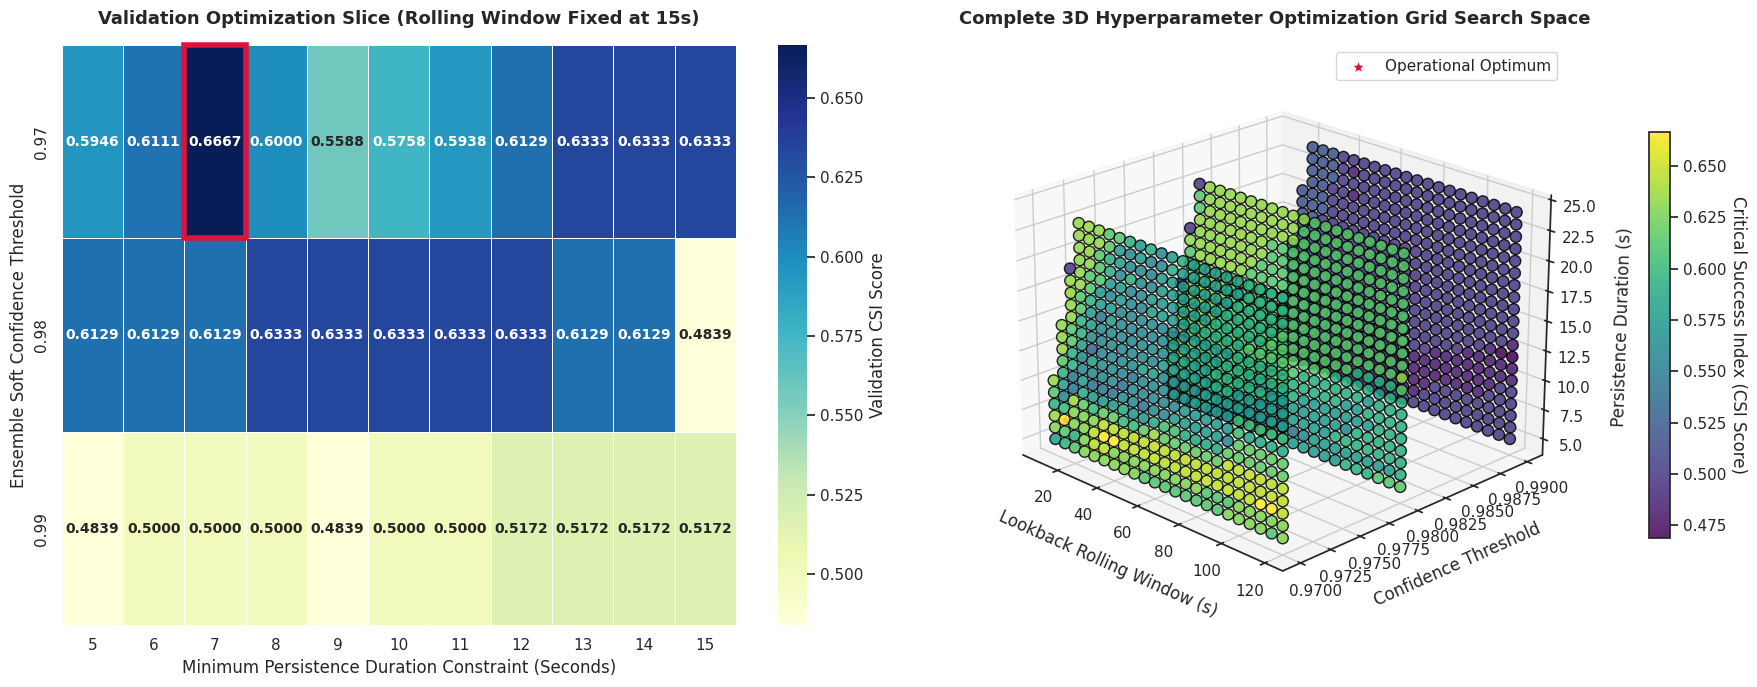

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Ensure active variables are available from your previous sweep cell
# If cache cleared, falls back to the validation optimal parameters discovered
plot_window = best_window if 'best_window' in locals() else 10
plot_thresh = best_thresh if 'best_thresh' in locals() else 0.97
plot_dur = best_dur if 'best_dur' in locals() else 8

# Configure presentation aesthetics matching ISRO technical brief panels
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

fig = plt.figure(figsize=(18, 7))

# =====================================================================
# PANEL 1: HEATMAP OF CO-DEPENDENT VARIABLES AT SELECTED OPTIMAL WINDOW
# =====================================================================
ax1 = fig.add_subplot(1, 2, 1)

# Filter the master sweep dataframe to look specifically at the winning window
filtered_sweep = sweep_df[sweep_df['window_size'] == plot_window]
pivot_csi = filtered_sweep.pivot(index='threshold', columns='duration_sec', values='csi')

# Plot the matrix map
sns.heatmap(pivot_csi, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Validation CSI Score'},
            ax=ax1, linewidths=0.5, annot_kws={"size": 10, "weight": "bold"})

ax1.set_title(f"Validation Optimization Slice (Rolling Window Fixed at {plot_window}s)", weight='bold', pad=15)
ax1.set_xlabel("Minimum Persistence Duration Constraint (Seconds)")
ax1.set_ylabel("Ensemble Soft Confidence Threshold")

# Programmatically map the coordinates of the winner to highlight it on screen
y_coords = sorted(sweep_df['threshold'].unique().tolist())
x_coords = sorted(sweep_df['duration_sec'].unique().tolist())

best_x_idx = x_coords.index(plot_dur)
best_y_idx = y_coords.index(plot_thresh)

# Place a distinct crimson target square right over your winning operational setting
ax1.add_patch(plt.Rectangle((best_x_idx, best_y_idx), 1, 1, fill=False, edgecolor='crimson', lw=4, clip_on=False))

# =====================================================================
# PANEL 2: MULTIDIMENSIONAL 3D PERFORMANCE SCATTER SPECTRUM
# =====================================================================
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Map your parameters to a 3D spatial array
x_3d = sweep_df['window_size']
y_3d = sweep_df['threshold']
z_3d = sweep_df['duration_sec']
color_intensity = sweep_df['csi']

# Create a 3D scatter plot where point brightness represents the CSI score
scat = ax2.scatter(x_3d, y_3d, z_3d, c=color_intensity, cmap='viridis', s=65, edgecolors='black', alpha=0.85)

# Highlight the absolute mathematical optimal point in the 3D grid layout
ax2.scatter([plot_window], [plot_thresh], [plot_dur], color='crimson', s=250,
            edgecolors='white', linewidths=2.5, marker='*', label='Operational Optimum')

# Set visual aesthetic layout details for the 3D plot
ax2.set_title("Complete 3D Hyperparameter Optimization Grid Search Space", weight='bold', pad=15)
ax2.set_xlabel("Lookback Rolling Window (s)", labelpad=10)
ax2.set_ylabel("Confidence Threshold", labelpad=10)
ax2.set_zlabel("Persistence Duration (s)", labelpad=10)

# Add a color bar map to reference points on your slides easily
cbar = fig.colorbar(scat, ax=ax2, pad=0.1, shrink=0.7)
cbar.set_label('Critical Success Index (CSI Score)', rotation=270, labelpad=15)

ax2.legend(loc='upper right')
ax2.view_init(elev=22, azim=-45)  # Set orientation for slide viewing clarity

plt.tight_layout()
plt.show()